# 05 — event bars: the catalogue, and any threshold you like

`lake.gold.bars` holds tick, volume and dollar bars at **one canonical threshold per symbol** (`config/bars.yaml`, sized so the busiest venue prints ~100 bars/day). It is the dataset a desk is handed: cross-venue comparable, fixed point, every row stamped with the `gold.trades` snapshot it came from. Any other threshold is `k2lake.bars()` over `gold.trades` in DuckDB — same definition, no second table.

A bar is a *cumulative bucket*: trade → bar k of its UTC day when k·T ≤ (the day's total before it) < (k+1)·T. Not a reset-after-crossing bar, on purpose: this form is one window expression in Spark, DuckDB and a twenty-line Python reference, and the three agree at tolerance zero (`scripts/parity-bars.sh`).

In [1]:
from datetime import timedelta

from k2lake import connect, pin, bars, SCALE
con = connect()
PIN = pin(con)   # every query below reads these snapshot ids, never the moving head
DAY = con.sql("SELECT max(day) FROM pinned.gold_bars").fetchone()[0]
print('day', DAY)
con.sql("SELECT bar_kind, exchange, count(*) AS bars, min(day) AS first_day, max(day) AS last_day FROM pinned.gold_bars GROUP BY ALL ORDER BY 1, 2").show()

pinned 18 tables at commit 1412e40
  audit.checks                 3136935192702395685
  gold.bars                    7918366944768104972
  gold.bbo_1s                  2862098228993760786
  gold.book_state              3786705358869876366
  gold.book_top20              6494718949887958007
  gold.dim_instrument          5170638083154339835
  gold.dim_venue               2633954285049042930
  gold.ohlcv_1d                2413545605360415502
  gold.ohlcv_1h                5151439659956556490
  gold.ohlcv_1m                2773946558635215982
  gold.ohlcv_5m                5863343548664890857
  gold.trades                  393432132789933568
  silver.book_binance          5746102258949859110
  silver.book_coinbase         6226364587198779054
  silver.book_kraken           3394954948427953133
  silver.trades_binance        8774579074731501963
  silver.trades_coinbase       4049989842012185004
  silver.trades_kraken         8750673137000106519
day 2026-09-03
┌──────────┬──────────┬───────┬──

BTC/USD dollar bars on the two venues that quote it in USD. Each bar is ~$6 M of notional; Coinbase prints three of them for every one Kraken does, which is the liquidity difference showing rather than a threshold to tune.

In [2]:
con.sql(f"""
SELECT exchange, bar_seq, open_time, close_time,
       open_e8 / {SCALE} AS open, close_e8 / {SCALE} AS close,
       volume_e8 / {SCALE} AS volume, quote_volume_e8 / {SCALE} AS quote_volume, trade_count,
       epoch(close_time) - epoch(open_time) AS seconds
FROM pinned.gold_bars
WHERE canonical_symbol = 'BTC/USD' AND bar_kind = 'dollar' AND day = DATE '{DAY}'
ORDER BY exchange, bar_seq
""").show(max_rows=12)

┌──────────┬─────────┬───────────────────────────────┬───────────────────────────────┬──────────┬──────────┬─────────────┬──────────────────┬─────────────┬────────────────────┐
│ exchange │ bar_seq │           open_time           │          close_time           │   open   │  close   │   volume    │   quote_volume   │ trade_count │      seconds       │
│ varchar  │  int32  │   timestamp with time zone    │   timestamp with time zone    │  double  │  double  │   double    │      double      │    int64    │       double       │
├──────────┼─────────┼───────────────────────────────┼───────────────────────────────┼──────────┼──────────┼─────────────┼──────────────────┼─────────────┼────────────────────┤
│ coinbase │       0 │ 2026-09-03 12:46:54.856296+00 │ 2026-09-03 12:55:49.260562+00 │ 78310.26 │  78600.0 │ 76.56608667 │ 6006253.12094027 │        4348 │  534.4042658805847 │
│ coinbase │       1 │ 2026-09-03 12:55:49.260642+00 │ 2026-09-03 12:59:51.349245+00 │  78600.0 │ 78578.96 │ 76.619

Bar duration is the point of an event bar: it shrinks when the market is busy and stretches when it is quiet, so each bar carries roughly the same information. Time bars (`gold.ohlcv_*`) do the opposite.

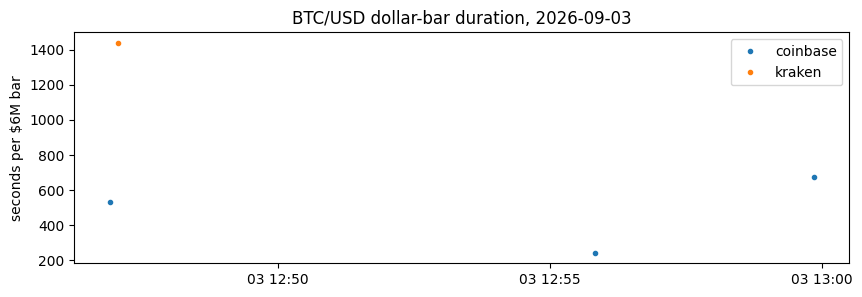

In [3]:
import matplotlib.pyplot as plt
df = con.sql(f"""
SELECT exchange, open_time, epoch(close_time) - epoch(open_time) AS seconds
FROM pinned.gold_bars WHERE canonical_symbol = 'BTC/USD' AND bar_kind = 'dollar' AND day = DATE '{DAY}'
""").df()
fig, ax = plt.subplots(figsize=(10, 3))
for ex, g in df.groupby('exchange'):
    ax.plot(g['open_time'], g['seconds'], marker='.', linestyle='', label=ex)
ax.set_ylabel('seconds per $6M bar'); ax.set_title(f'BTC/USD dollar-bar duration, {DAY}'); ax.legend()
plt.show()

Any other threshold is a function, not a table. `bars()` runs the same window SQL over `gold.trades` in DuckDB; here $1 M bars for one venue, one day — ~6× as many rows as the catalogue's $6 M bars.

In [4]:
con.sql(f"SELECT count(*) AS catalogue_bars FROM pinned.gold_bars WHERE canonical_symbol = 'BTC/USD' AND exchange = 'coinbase' AND bar_kind = 'dollar' AND day = DATE '{DAY}'").show()
adhoc = bars(con, 'dollar', 1_000_000, symbol='BTC/USD', exchange='coinbase', start=DAY, end=DAY + timedelta(days=1))
adhoc.aggregate('count(*) AS adhoc_bars').show()
adhoc.limit(5).show()

┌────────────────┐
│ catalogue_bars │
│     int64      │
├────────────────┤
│              3 │
└────────────────┘

┌────────────┐
│ adhoc_bars │
│   int64    │
├────────────┤
│         18 │
└────────────┘

┌──────────┬──────────────────┬──────────┬──────────────┬────────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬─────────────────┬─────────────┬───────────────────────────────┬───────────────────────────────┐
│ exchange │ canonical_symbol │ bar_kind │  threshold   │    day     │ bar_seq │    open_e8    │    high_e8    │    low_e8     │   close_e8    │ volume_e8  │ quote_volume_e8 │ trade_count │           open_time           │          close_time           │
│ varchar  │     varchar      │ varchar  │ decimal(8,1) │    date    │  int32  │     int64     │     int64     │     int64     │     int64     │   int64    │      int64      │    int64    │   timestamp with time zone    │   timestamp with time zone    │
├──────────┼──────────────────┼─

The catalogue is reproducible by construction: `bars()` at the catalogue's own threshold returns the catalogue's rows. This cell is the parity check `scripts/parity-bars.sh` runs across every symbol and every kind, in miniature.

In [5]:
mine = bars(con, 'dollar', 6_000_000, symbol='BTC/USD', start=DAY, end=DAY + timedelta(days=1)).df()
theirs = con.sql(f"SELECT exchange, canonical_symbol, bar_kind, day, bar_seq, open_e8, high_e8, low_e8, close_e8, volume_e8, quote_volume_e8, trade_count, open_time, close_time FROM pinned.gold_bars WHERE canonical_symbol = 'BTC/USD' AND bar_kind = 'dollar' AND day = DATE '{DAY}' ORDER BY exchange, bar_seq").df()
assert len(mine) > 0, 'no trades in the catalogue day — the lake is empty, so parity would pass vacuously'
cols = ['exchange', 'bar_seq', 'open_e8', 'high_e8', 'low_e8', 'close_e8', 'volume_e8', 'quote_volume_e8', 'trade_count']
same = mine[cols].reset_index(drop=True).equals(theirs[cols].reset_index(drop=True))
print(len(mine), 'bars from bars(),', len(theirs), 'in the catalogue, identical:', same)
assert same

4 bars from bars(), 4 in the catalogue, identical: True
